# 第6章　勾配ブースティング

## 6.4　Pythonで勾配ブースティング

### コード6.1　データの取得

In [1]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 35.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=b26f77c87dfec8133d535fd5f15fc2e8a50e9a6e039fb645c0b46b2381d92e08
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import fetch_california_housing
import japanize_matplotlib

# データセットをロード
print("California Housing データセットをロードしています...")
data = fetch_california_housing(as_frame=True)
df = data.frame

# データセットの説明を保存
data_description = data.DESCR
with open("dataset_description.txt", "w") as f:
    f.write(data_description)

df

California Housing データセットをロードしています...


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### コード6.2　データの理解

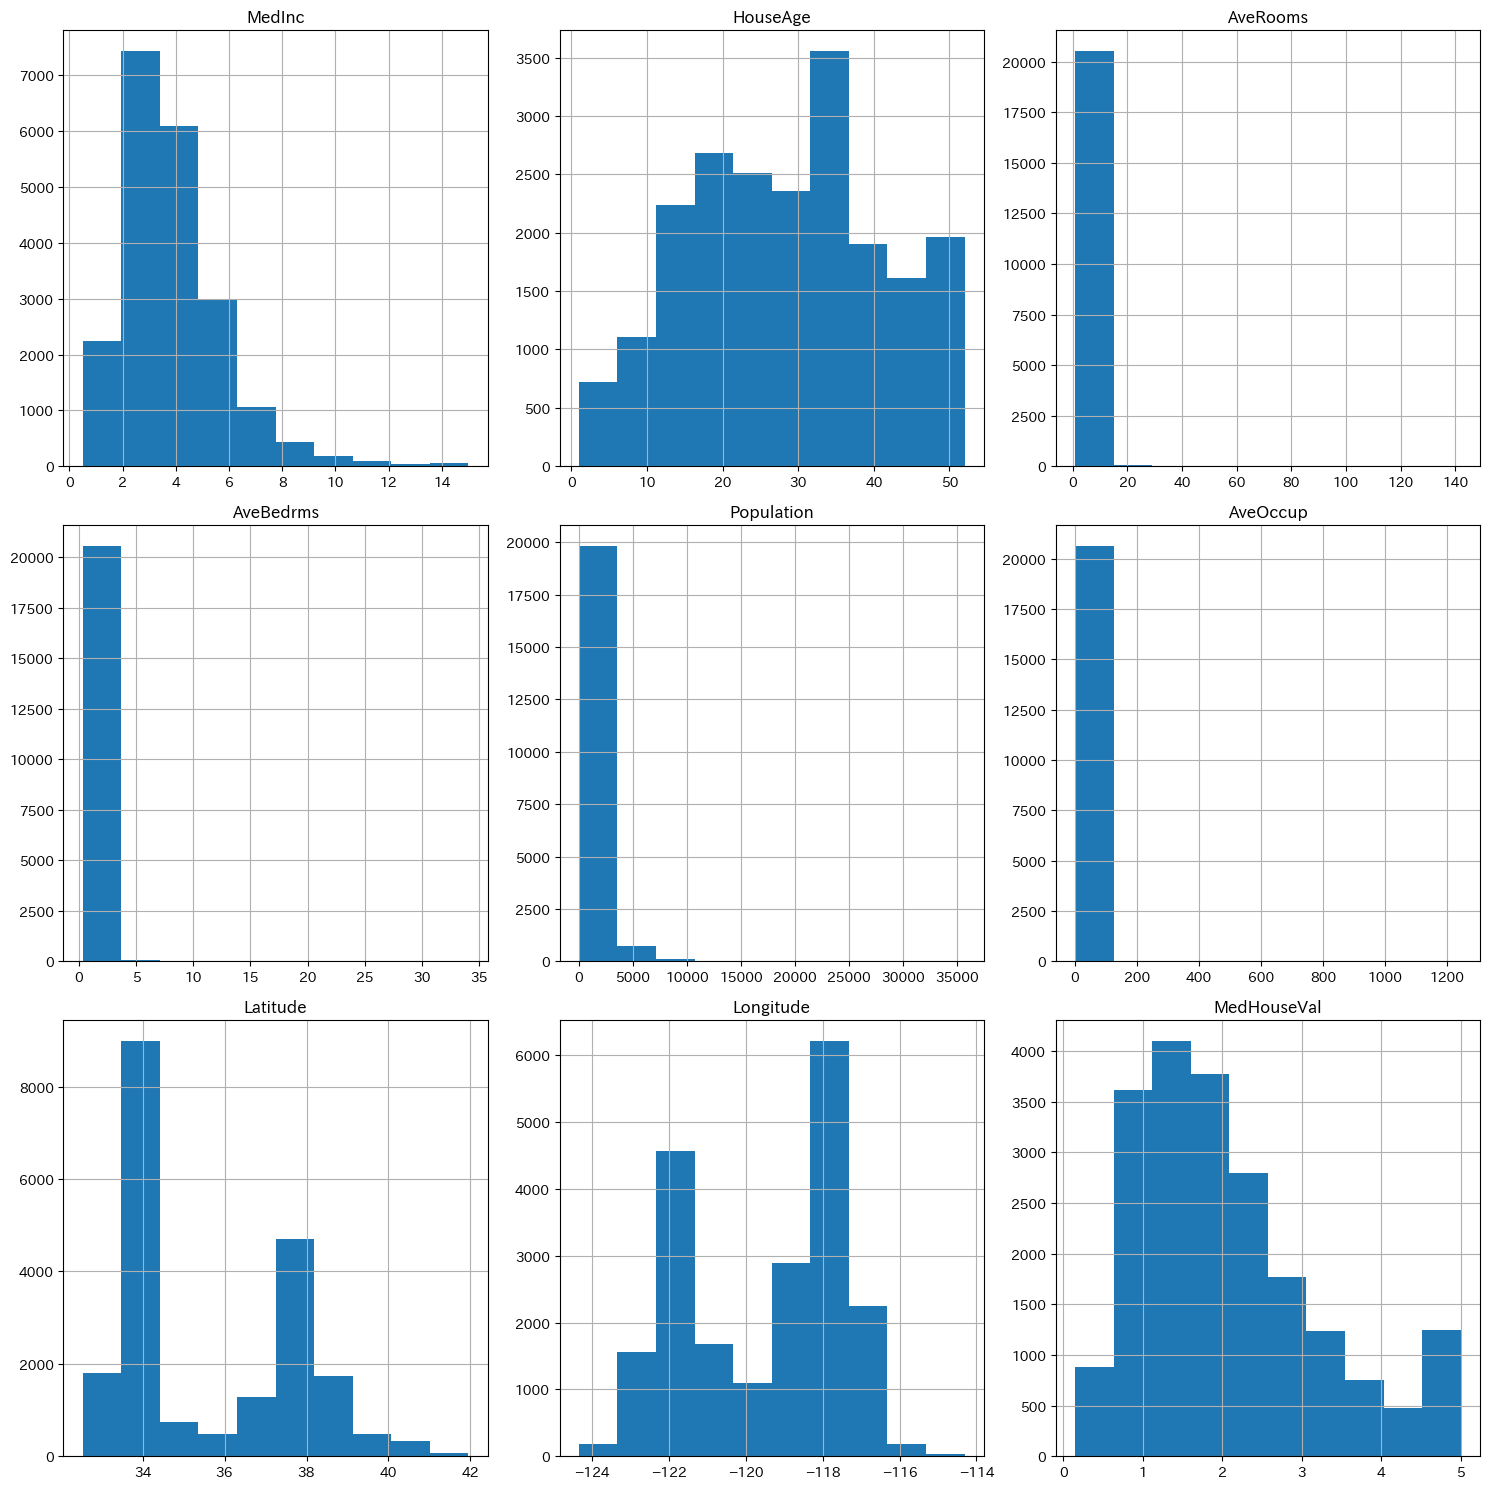

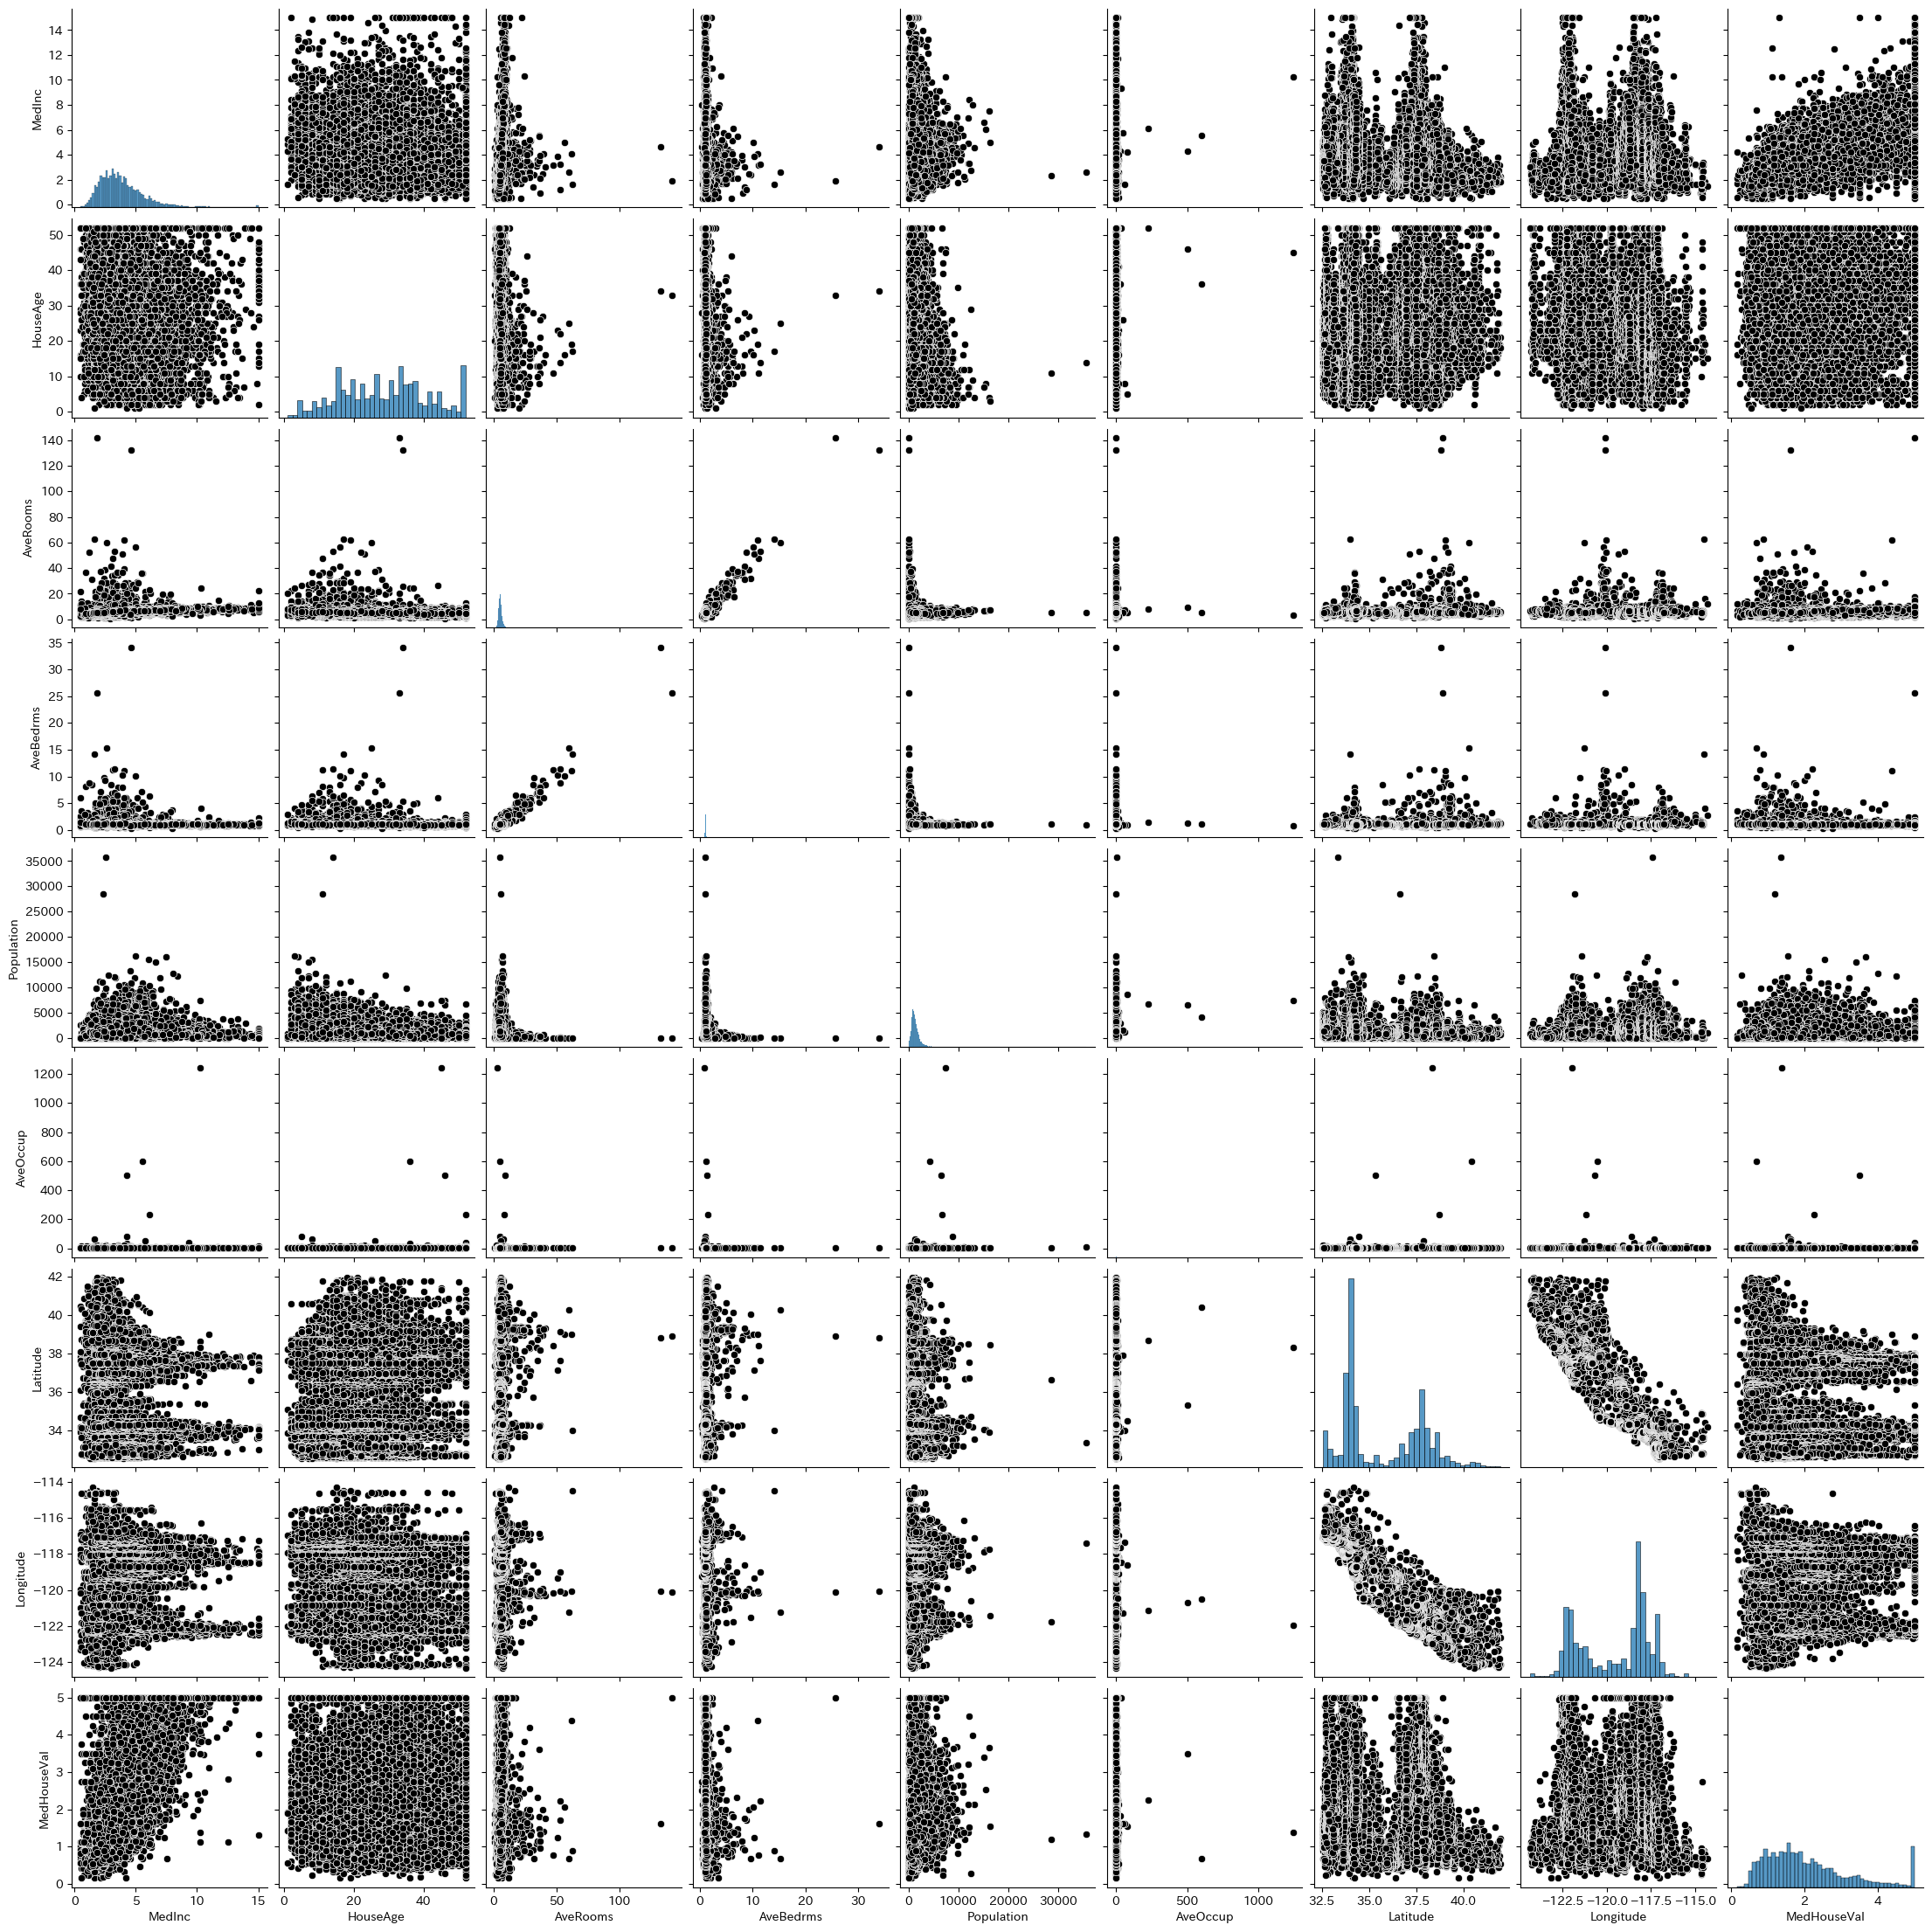

In [3]:
# ヒストグラムを表示して保存
df.hist(figsize=(15, 15))
plt.tight_layout()
histogram_path = "histogram.svg"
plt.savefig(histogram_path, format='svg', dpi=300)
plt.show()

# ペアプロットを作成し保存
sns.pairplot(df, diag_kind="hist", plot_kws={'color': 'black'})
plt.savefig("pairplot.svg", format='svg', dpi=300)
plt.show()

### コード6.3　データの分割，回帰木モデルの学習

In [4]:
# 特徴量 (X) とターゲット (y) に分割
X = df.drop("MedHouseVal", axis=1)
# ターゲット (住宅価格)
y = df["MedHouseVal"]

# データをトレイン (トレーニング用) とテスト用に分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting Regressor のモデルを定義
# ハイパーパラメータを指定 (初学者向けに設定)
gbm = GradientBoostingRegressor(
    n_estimators=100,       # 木の数 (弱学習器の数)
    learning_rate=0.1,      # 学習率
    max_depth=3,            # 各木の深さ
    min_samples_split=2,    # ノード分割の最小サンプル数
    subsample=0.8,          # サブサンプル比率
    random_state=42         # 再現性のためのランダムシード
)

# モデルの学習
print("Gradient Boosting Regressor をトレーニングしています...")
gbm.fit(X_train, y_train)

Gradient Boosting Regressor をトレーニングしています...


GradientBoostingRegressor(random_state=42, subsample=0.8)

### コード6.4　回帰木モデルの評価

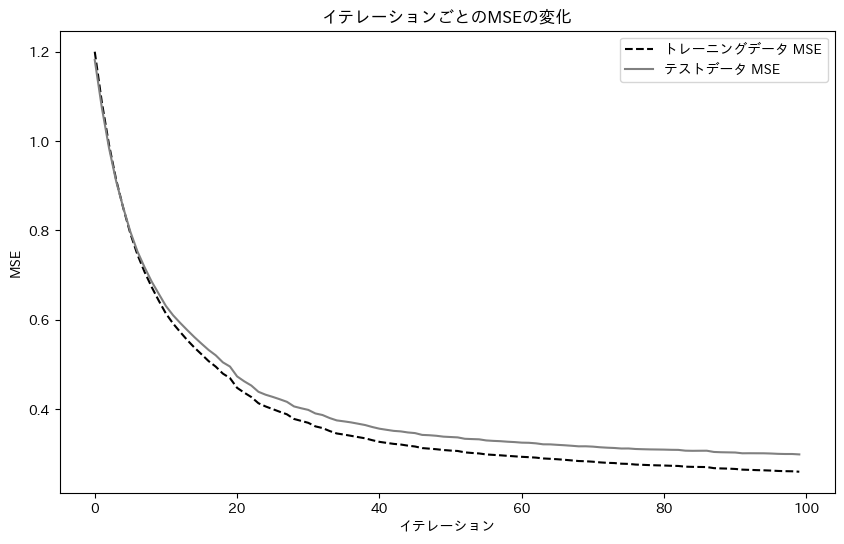

特徴量の重要度をプロットしています...


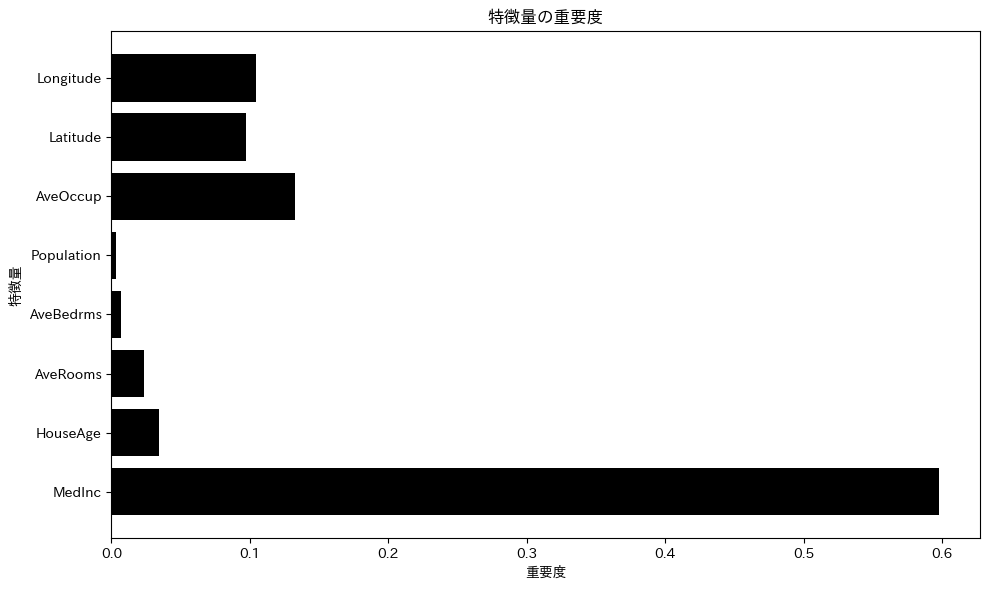

最終評価を計算しています...
すべての結果が保存されました


In [5]:
# イテレーションごとのMSE (平均二乗誤差) を記録
train_mse = []
test_mse = []

for y_pred_train, y_pred_test in zip(gbm.staged_predict(X_train), gbm.staged_predict(X_test)):
    train_mse.append(mean_squared_error(y_train, y_pred_train))
    test_mse.append(mean_squared_error(y_test, y_pred_test))

# イテレーションごとのMSEをプロット
plt.figure(figsize=(10, 6))
plt.plot(train_mse, label='トレーニングデータ MSE', color='black', linestyle='--')
plt.plot(test_mse, label='テストデータ MSE', color='gray')
plt.xlabel("イテレーション")
plt.ylabel("MSE")
plt.legend()
plt.title("イテレーションごとのMSEの変化")
plt.savefig("mse_vs_iteration.svg", format='svg', dpi=300)
plt.show()

# 特徴量の重要度を可視化
print("特徴量の重要度をプロットしています...")
feature_importances = gbm.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances, color='black')
plt.xlabel("重要度")
plt.ylabel("特徴量")
plt.title("特徴量の重要度")
plt.tight_layout()
plt.savefig("feature_importances.svg", format='svg', dpi=300)
plt.show()

# 最終的なMSEを計算
print("最終評価を計算しています...")
final_train_mse = train_mse[-1]
final_test_mse = test_mse[-1]

# 評価指標を保存
metrics = {
    "最終トレーニング MSE": final_train_mse,
    "最終テスト MSE": final_test_mse
}
pd.DataFrame([metrics]).to_csv("final_metrics.csv")

print("すべての結果が保存されました")